#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre: Jose Angel Barajas Flores**

* **matrícula: A01797221**

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [252]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [253]:
nltk.download('punkt')    # es un tokenizador que ayuda a dividr el texto en enunciados mediante un modelo no-supervisado.
nltk.download('stopwords')    # para tener acceso a "stopwords" en varios idiomas.
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\baraj\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**

El modelo intenta predecir comentarios como 1=Positivos, 0=Negativos.

Falso - Negativo = El model predice que un comentario es negativo pero en realidad es Positivo. Dependiendo del uso que tenga la informacion esto podria subestimar servicios de buena calidad, perder retroalimentacion positiva, afectar metricas de satisfaccion

Falso - Positivo = El modelo predice que un comentario es positivo pero en realidad es Negativo. Dependiendo del uso que tenga la informacion esto podria generar malas decisiones de negocio, recomendaciones incorrectas, falsa percepcion de satisfaccion del cliente.

El error mas grave depende del contexto sin embargo, en mi opinion un falso positivo suele considerarse mas grave por que puede generar una falsa percepcion de satisfaccion del producto o servicio, lo cual puede conllevar a ignorar problemas reales. 



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [254]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [255]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [256]:
# Puedes modificar en dado caso la ruta de los archivos:

dfa = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv(r'D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')


print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [257]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [258]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [259]:
dfi.head(50)

,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
5,"The rest of the movie lacks art, charm, meanin...",0
6,Wasted two hours.,0
7,Saw the movie today and thought it was a good ...,1
8,A bit predictable.,0
9,Loved the casting of Jimmy Buffet as the scien...,1


In [260]:
newdfi=[]     # lista de salida que deberá tener los 1000 registros ya debidamente separados.



################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:


# leer archivo completo como texto
with open(r"D:\ML\Projects\Project_6_TC55043.10_NLP\TC55043.10_NLP\data\Clase 3\imdb_labelled.txt",
          "r",
          encoding="utf-8") as f:
    
    raw_text = f.read()

# encontrar TODOS los registros
# (.*?\t[01])
# -> Captura el contenido principal del registro.
#
# .      = cualquier carácter
# *?     = repetir de manera NO codiciosa (lazy)
# \t     = tabulador
# [01]   = acepta únicamente 0 o 1
# re.DOTALL
# -> Permite que "." también capture saltos de línea.
#    Muy útil para comentarios multilínea.


records = re.findall(r'(.*?\t[01])(?:\n|$)', raw_text, re.DOTALL)


for rec in records:

    review, label = rec.rsplit('\t', 1)

    newdfi.append({
        "review": review.strip(),
        "label": int(label.strip())
    })

# convertir a dataframe
newdfi = pd.DataFrame(newdfi)


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [261]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[0:21]

,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1
5,"The rest of the movie lacks art, charm, meanin...",0
6,Wasted two hours.,0
7,Saw the movie today and thought it was a good ...,1
8,A bit predictable.,0
9,Loved the casting of Jimmy Buffet as the scien...,1


Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [262]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [263]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  3000 non-null   object
 1   label   3000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 47.0+ KB


In [264]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [265]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [266]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**


Los casos como 1125 y 1788 representan informacion semantica importante aunque no contienen caracteres alfabeticos. Eliminarlos completamente provocaria un sesgo en la informacion generado por una limitacion tecnica, sin embargo esta informacion es util para el analisis de sentimiento. 

ChatGPT. Una mejor estrategia consiste en transformar estos patrones numéricos en tokens semánticos como "positive_rating" antes del proceso de limpieza, preservando así el significado del comentario y evitando registros vacíos.



##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [267]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

In [268]:
X

0       So there is no way for me to plug it in here i...
1                             Good case, Excellent value.
2                                  Great for the jawbone.
3       Tied to charger for conversations lasting more...
4                                       The mic is great.
                              ...                        
2995    I think food should have flavor and texture an...
2996                             Appetite instantly gone.
2997    Overall I was not impressed and would not go b...
2998    The whole experience was underwhelming, and I ...
2999    Then, as if I hadn't wasted enough of my life ...
Name: review, Length: 3000, dtype: object

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [269]:
def clean_tok(docs):

    # ==========================================
    # Convert text to lowercase
    # ==========================================
    docs = docs.lower()

    # ==========================================
    # Expand common English negation contractions
    # IMPORTANT:
    # This must happen BEFORE regex cleaning,
    # otherwise:
    # "wasn't" -> "wasn"
    # "don't"  -> "don"
    # ==========================================

    contractions = {
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "wasn't": "was not",
        "weren't": "were not",
        "isn't": "is not",
        "aren't": "are not",
        "can't": "can not",
        "couldn't": "could not",
        "won't": "will not",
        "wouldn't": "would not",
        "shouldn't": "should not",
        "haven't": "have not",
        "hasn't": "has not",
        "hadn't": "had not"
    }

    for contraction, expanded in contractions.items():
        docs = docs.replace(contraction, expanded)

    # ==========================================
    # Extra safety replacement for remaining n't
    # ==========================================
    docs = docs.replace("n't", " not")

    # ==========================================
    # Keep only alphabetic characters
    # ==========================================
    text = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]', ' ', docs)

    # ==========================================
    # Tokenization
    # ==========================================
    words = text.split()

    # ==========================================
    # Remove very short words
    # but preserve useful sentiment words
    # ==========================================
    keep_short_words = {'no', 'ok'}

    words = [
        w for w in words
        if len(w) > 1 or w in keep_short_words
    ]

    # ==========================================
    # Remove stopwords
    # IMPORTANT:
    # mystopwords already preserves negwords
    # ==========================================
    words = [w for w in words if w not in mystopwords]

    return words

In [270]:
# Aplicamos el proceso de limpieza y tokenización:

Xcleantok = [clean_tok(x) for x in X]

Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [271]:
for x in Xcleantok[0:10]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']
['jiggle', 'plug', 'get', 'line', 'right', 'get', 'decent', 'volume']
['several', 'dozen', 'several', 'hundred', 'contacts', 'imagine', 'fun', 'sending', 'one', 'one']
['razr', 'owner', 'must']
['needless', 'say', 'wasted', 'money']
['waste', 'money', 'time']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [272]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

# Aquí puedes incluir las librerías, paquetes o líneas de código necesarias para
# el proceso de limpieza adicional de esta pregunta:


def clean_doc(doc):

    tokens = []

    negation_words = {'not', 'no', 'nor', 'never'}

    for word in doc:

        if word in negation_words:
            lemma = word
        else:
            lemma = lemmatizer.lemmatize(word)

        if len(lemma) > 1:
            tokens.append(lemma)

    return tokens


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
  ##############################################################################

In [273]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [274]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'unless', 'go', 'converter'],
 ['good', 'case', 'excellent', 'value'],
 ['great', 'jawbone'],
 ['tied', 'charger', 'conversation', 'lasting', 'minute', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [275]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

pos_tok=[]  # inicializamos listas de los tokens positivos y negativos
neg_tok=[] 

for x,c in zip(Xclean, y):   
  if c==1:
    pos_tok.extend(x)   # tokens usados en comentarios positivos
  else: 
    neg_tok.extend(x)   # tokens usados en comentarios negativos

pt = ' '.join(pos_tok)   # requerimos un solo string por cada clase para la nube de palabras.
nt = ' '.join(neg_tok)



# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

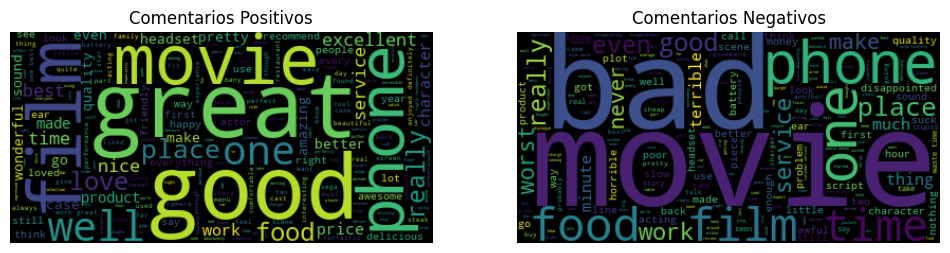

In [276]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,12))

# Nube de palabras de comentarios positivos:
wordcloudnn = WordCloud().generate(pt)
ax1.imshow(wordcloudnn, interpolation='bilinear')
ax1.axis("off")
ax1.set_title('Comentarios Positivos')

# Nube de palabras de comentarios negativos:
wordcloudnn = WordCloud().generate(nt)
ax2.imshow(wordcloudnn, interpolation='bilinear')
ax2.axis("off")
ax2.set_title('Comentarios Negativos')

plt.show()


# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**


Las nubes de palabras permiten identificar visualmente los términos más frecuentes en comentarios positivos y negativos. Se observa que los comentarios positivos contienen palabras asociadas con satisfacción como “good”, “great” y “excellent”, mientras que los negativos incluyen términos como “bad”, “problem” y “waste”. Sin embargo, algunas palabras frecuentes aparecen en ambas clases, por lo que la nube debe interpretarse como una herramienta exploratoria y no como una clasificación definitiva del sentimiento.


###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [277]:
from sklearn.model_selection import train_test_split

# shuffle=True randomly mixes the samples before splitting.
# random_state=1 makes the split reproducible.
# stratify=y preserves the same class distribution
# across train, validation, and test datasets.

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1,stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1,stratify=y_val_and_test)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2100 2100
X,y Val: 450 450
X,y Test 450 450


In [278]:
print('\nTrain distribution:')
print(y_train.value_counts(normalize=True))

print('\nValidation distribution:')
print(y_val.value_counts(normalize=True))

print('\nTest distribution:')
print(y_test.value_counts(normalize=True))


Train distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Validation distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Test distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [279]:
from collections import Counter

In [280]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(20))

Longitud del diccionario: 3683

(word,frequency):
[('not', 420), ('good', 165), ('movie', 149), ('great', 148), ('phone', 141), ('film', 119), ('one', 111), ('like', 93), ('food', 93), ('time', 87), ('place', 86), ('work', 81), ('service', 78), ('really', 76), ('well', 69), ('bad', 68), ('would', 64), ('no', 62), ('also', 57), ('ever', 57)]


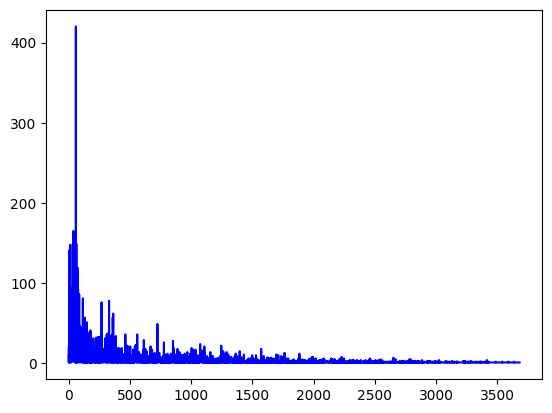

In [281]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

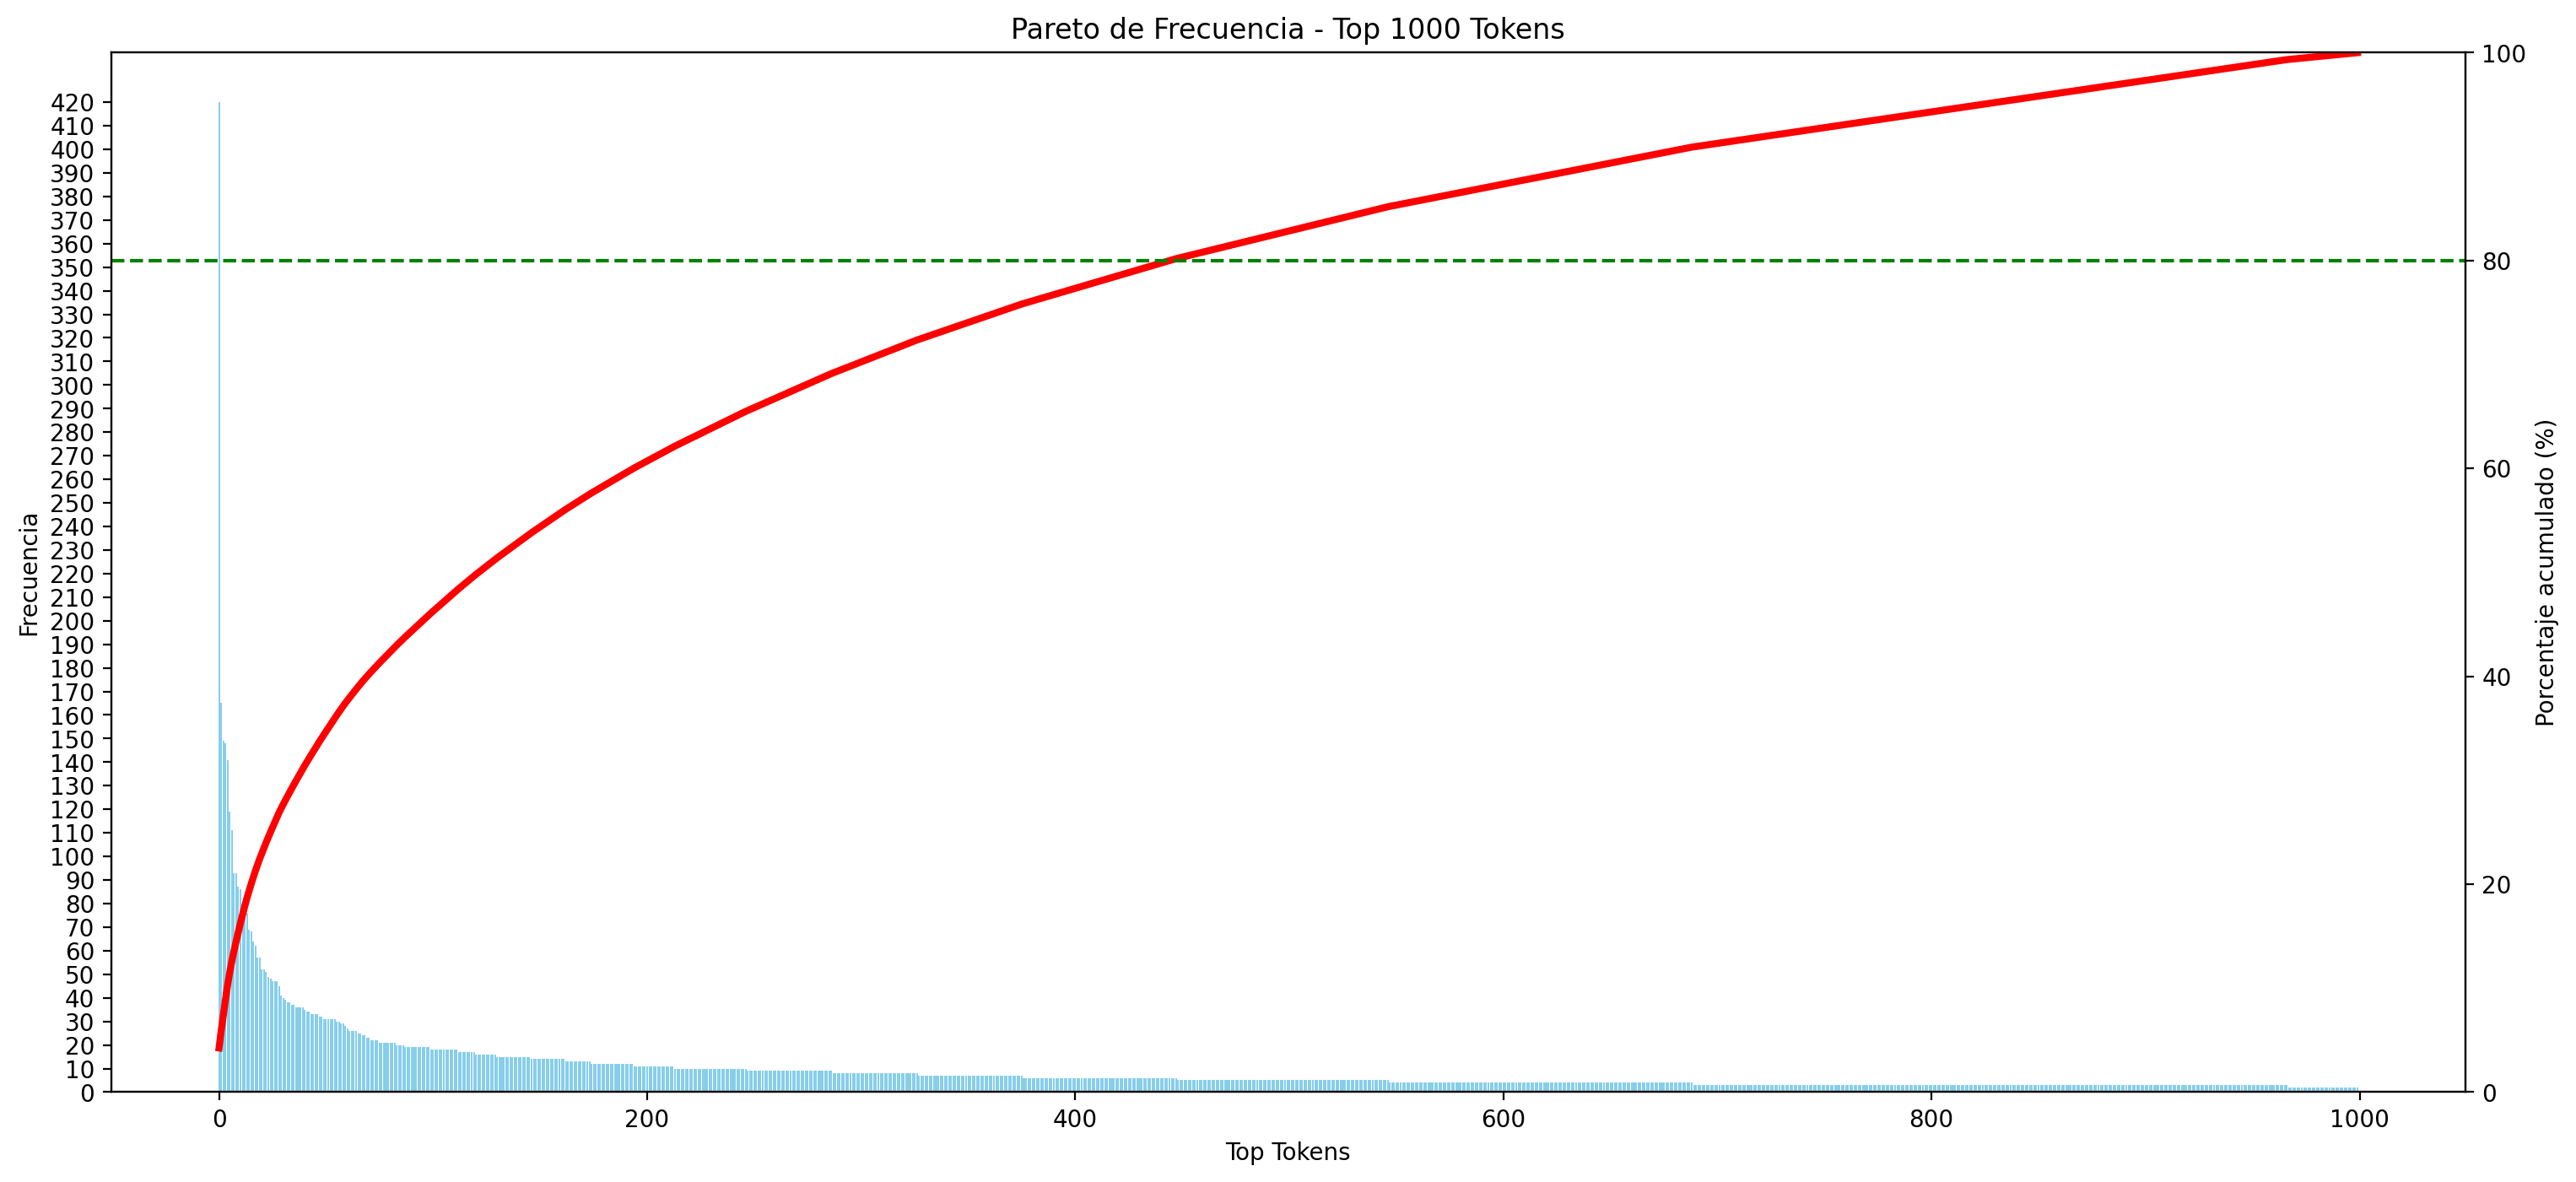

In [282]:
import numpy as np
import matplotlib.pyplot as plt

# ordenar frecuencias
freqs = sorted(midiccionario.values(), reverse=True)

# limitar a top N
top_n = 1000

freqs_top = freqs[:top_n]

# porcentaje acumulado
cumperc = np.cumsum(freqs_top) / np.sum(freqs_top) * 100

# gráfica
fig, ax1 = plt.subplots(figsize=(18,8), dpi=200)

# barras
ax1.bar(range(top_n), freqs_top, color='skyblue')

ax1.set_yticks(range(0, max(freqs)+10, 10))
ax1.set_xlabel('Top Tokens')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Pareto de Frecuencia - Top {top_n} Tokens')

# segunda escala
ax2 = ax1.twinx()

# línea acumulada
ax2.plot(range(top_n), cumperc, color='red', linewidth=3)

ax2.set_ylabel('Porcentaje acumulado (%)')
ax2.set_ylim(0, 100)

# línea 80%
ax2.axhline(80, color='green', linestyle='--')

plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [283]:
######################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:
######################################################################

min_freq = 3

# ==========================================================
# Keep only words appearing at least min_freq times
# This helps reduce sparsity and overfitting.
# ==========================================================

midicc = {
    word: freq
    for word, freq in midiccionario.items()
    if freq >= min_freq
}

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
######################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:10])

Nueva longitud del nuevo vocabulario: 967
[('people', 20), ('hear', 10), ('talk', 7), ('pull', 3), ('phone', 141), ('comment', 3), ('black', 15), ('fire', 3), ('red', 4), ('great', 148)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [284]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [285]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(30):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['people', 'couldnt', 'hear', 'talk', 'pull', 'earphone', 'talk', 'phone']
Después: ['people', 'hear', 'talk', 'pull', 'talk', 'phone']
Antes: ['posted', 'detailed', 'comment', 'grey', 'black', 'phone', 'fire', 'red', 'great', 'color']
Después: ['comment', 'black', 'phone', 'fire', 'red', 'great', 'color']
Antes: ['hoping']
Después: ['hoping']
Antes: ['well', 'would', 'given', 'godfather', 'zero', 'star', 'possible']
Después: ['well', 'would', 'given', 'zero', 'star', 'possible']
Antes: ['acting', 'like', 'watching', 'wooden', 'puppet', 'moving', 'around', 'reading', 'book', 'bad']
Después: ['acting', 'like', 'watching', 'puppet', 'moving', 'around', 'reading', 'book', 'bad']
Antes: ['hear', 'garbage', 'audio']
Después: ['hear', 'garbage', 'audio']
Antes: ['happy', 'purchase', 'good', 'quality', 'low', 'price']
Después: ['happy', 'purchase', 'good', 'quality', 'low', 'price']
Antes: ['felt', 'insulted', 'disrespected', 'could', 'talk', 'judge', 'another', 'human', 'like']
Despué

###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [286]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

people hear talk pull talk phone
comment black phone fire red great color
hoping


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [287]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
#countvectorizer = CountVectorizer(min_df=3, ngram_range=(1,2))

train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:20,0:18])   # veamos las frecuencias de los primeros comentarios.

    people  hear  talk  pull  phone  comment  black  fire  red  great  color  \
0        1     1     2     1      1        0      0     0    0      0      0   
1        0     0     0     0      1        1      1     1    1      1      1   
2        0     0     0     0      0        0      0     0    0      0      0   
3        0     0     0     0      0        0      0     0    0      0      0   
4        0     0     0     0      0        0      0     0    0      0      0   
5        0     1     0     0      0        0      0     0    0      0      0   
6        0     0     0     0      0        0      0     0    0      0      0   
7        0     0     1     0      0        0      0     0    0      0      0   
8        0     0     0     0      0        0      0     0    0      0      0   
9        0     0     0     0      0        0      0     0    0      0      0   
10       0     0     0     0      0        0      0     0    0      0      0   
11       0     0     0     0      0     

In [288]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 2030700
Total de valores no cero: 9545
Total de valores cero: 2021155
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.53%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.47%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [289]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

from sklearn.feature_extraction.text import TfidfVectorizer


# Generamos matrices TF-IDF usando el mismo vocabulario
tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)
#using min_df instead of mivocab to be able to add ngram_range
#tfidfvectorizer = TfidfVectorizer(min_df=3, ngram_range=(1,2))

#fit_transform(train_x_docs) aprende el peso TF-IDF con el set de entrenamiento.
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)

#transform(val_x_docs) y transform(test_x_docs) aplican la misma lógica al set de validación y prueba.
val_x_tfidf = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf = tfidfvectorizer.transform(test_x_docs)
#No usamos fit_transform() en validación/test para evitar data leakage.

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(),  columns = tfidf_tokens)
print(df_tfidfvect.iloc[0:10,0:18])   # veamos algunos valores tf-idf de los primeros comentarios.

    people      hear      talk     pull     phone   comment     black  \
0  0.31718  0.350716  0.752138  0.40746  0.211327  0.000000  0.000000   
1  0.00000  0.000000  0.000000  0.00000  0.231681  0.446704  0.361452   
2  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
3  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
4  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
5  0.00000  0.544526  0.000000  0.00000  0.000000  0.000000  0.000000   
6  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
7  0.00000  0.000000  0.423969  0.00000  0.000000  0.000000  0.000000   
8  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   
9  0.00000  0.000000  0.000000  0.00000  0.000000  0.000000  0.000000   

       fire       red    great     color  hoping      well     would  \
0  0.000000  0.000000  0.00000  0.000000     0.0  0.000000  0.000000   
1  0.446704  0.432982  0.22633  0.421769     0.0  0.

##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [290]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [291]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Utiliza una semilla random_state=1 en los dos primeros modelos.

# Modelo de Regresión Logística (Logistic Regression):
modeloLRcount = LogisticRegression(
    random_state=1,
    max_iter=3000,
    C=0.1,
    solver='liblinear'
)

modeloLRcount.fit(train_x_count, y_train)


# Modelo Bosque Aleatorio (Random Forest):
modeloRFcount = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=4,
    random_state=1
)

modeloRFcount.fit(train_x_count, y_train)



# Modelos probabilístico Bayes Ingenuo (Naive Bayes):
modeloNBcount = MultinomialNB(
    alpha=10.0
)

modeloNBcount.fit(train_x_count, y_train)





# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRcount.score(val_x_count, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFcount.score(val_x_count, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBcount.score(val_x_count, y_val)))

LR: Train-accuracy: 87.19%
LR: Val-accuracy: 80%

RF: Train-accuracy: 83.33%
RF: Val-accuracy: 80.44%

NB: Train-accuracy: 86.19%
NB: Val-accuracy: 81.11%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**

GRID SEARCH PUEDE SER ENCONTRADO AL FINAL DEL DOCUMENTO

Los tres modelos obtuvieron resultados razonables tanto en entrenamiento como en validación, lo cual indica que no están subentrenados (underfitting).

Un modelo subentrenado normalmente presenta accuracies bajas tanto en train como en validation, ya que no logra aprender adecuadamente los patrones importantes del dataset.


Estos resultados demuestran que los modelos sí lograron aprender relaciones útiles entre las palabras y el sentimiento de los comentarios.

Además, las diferencias entre train y validation son moderadas, especialmente en el modelo de Random Forest, lo cual indica un buen balance entre capacidad de aprendizaje y generalización.

Durante el ejercicio también se observó que:

Modelos demasiado complejos incrementaban el accuracy de entrenamiento, pero generaban mayor overfitting.
Modelos demasiado regularizados reducían el overfitting, pero también reducían la capacidad predictiva.

También se observó que fue difícil lograr simultáneamente:

un test accuracy superior a 79%, y
una diferencia menor al 4% entre train y validation.

Esto ocurre porque el dataset utilizado es relativamente pequeño para tareas de NLP y contiene comentarios muy variados y ambiguos. En problemas de análisis de sentimiento, muchas palabras pueden cambiar de significado dependiendo del contexto, sarcasmo, expresiones informales o combinaciones específicas de palabras.

Además, al reducir demasiado la complejidad del modelo para disminuir el overfitting, el modelo pierde capacidad para capturar patrones útiles del lenguaje, reduciendo el desempeño en validación y prueba.





###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

##**Pregunta - 10:**

* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [292]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# Utiliza una semilla random_state=1 en los dos primeros modelos.


modeloLRtfidf = LogisticRegression(
    random_state=1,
    max_iter=3000,
    C=0.005,
    solver='liblinear'
)

modeloLRtfidf.fit(train_x_tfidf, y_train)


modeloRFtfidf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=8,
    random_state=1
)

modeloRFtfidf.fit(train_x_tfidf, y_train)


modeloNBtfidf = MultinomialNB(
    alpha=50.0
)

modeloNBtfidf.fit(train_x_tfidf, y_train)





# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################


print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%' % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%' % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%' % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 84.90%
LR: Val-accuracy: 82%

RF: Train-accuracy: 80.90%
RF: Val-accuracy: 79.33%

NB: Train-accuracy: 86.38%
NB: Val-accuracy: 81.56%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**

GRID SEARCH PUEDE SER ENCONTRADO AL FINAL DEL DOCUMENTO

Los modelos utilizando matrices **TF-IDF** también obtuvieron resultados adecuados tanto en entrenamiento como en validación, lo cual indica que **no presentan subentrenamiento (underfitting)**.

Un modelo subentrenado normalmente presenta accuracies bajas en ambos conjuntos, ya que no logra capturar patrones relevantes del lenguaje. En este caso, todos los modelos lograron accuracies superiores al 79% en validación, demostrando que sí aprendieron relaciones útiles entre las palabras y las etiquetas de sentimiento.


En particular, el modelo de **Random Forest** mostró una diferencia pequeña entre entrenamiento y validación, indicando un mejor control del overfitting y una capacidad de generalización más estable.

Durante los experimentos también se observó que aumentar demasiado la complejidad de los modelos incrementaba el accuracy de entrenamiento, pero provocaba mayores diferencias respecto al conjunto de validación.

Asimismo, reducir excesivamente la complejidad para disminuir el overfitting terminaba reduciendo la capacidad del modelo para aprender patrones útiles del texto.

Al igual que con las matrices CountVectorizer, fue difícil lograr simultáneamente:

* un accuracy alto en test,
* y una diferencia menor al 4% entre entrenamiento y validación.



###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

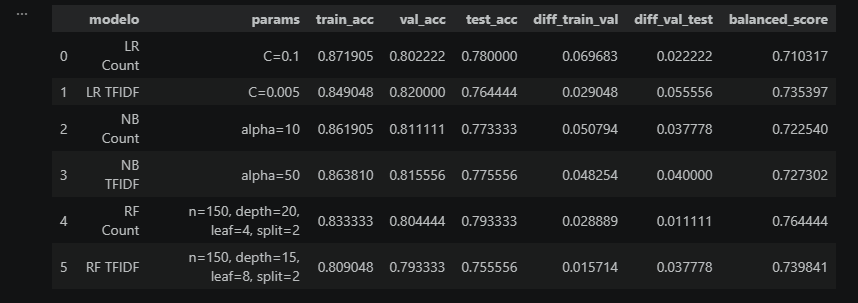

In [293]:
##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT :

from sklearn.metrics import confusion_matrix

# Mejor modelo encontrado:
mejor_modelo = RandomForestClassifier(
    n_estimators=150,
    max_depth=20,
    min_samples_leaf=4,
    min_samples_split=2,
    random_state=1
)

# Entrenamos nuevamente el mejor modelo usando CountVectorizer
mejor_modelo.fit(train_x_count, y_train)

# Conjunto de prueba asociado al mejor modelo:
test_x_asociada = test_x_count

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################



print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 79.33%

Matriz de confusión con el mejor modelo:
[[196  29]
 [ 64 161]]

Matriz de confusión con el mejor modelo en proporciones:
[[0.43555556 0.06444444]
 [0.14222222 0.35777778]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**


## Conclusiones sobre los retos de la actividad

# Conclusiones Finales

Durante esta actividad se desarrolló un pipeline completo de *Natural Language Processing (NLP)* orientado al análisis de sentimiento utilizando comentarios positivos y negativos provenientes de diferentes dominios.

El proceso comenzó con la integración y limpieza del dataset. Inicialmente fue necesario reconstruir registros dañados mediante expresiones regulares debido a problemas causados por saltos de línea y tabulaciones dentro de algunos comentarios. Posteriormente se realizó un proceso de normalización del texto que incluyó:

* conversión a minúsculas,
* eliminación de caracteres no alfabéticos,
* tokenización,
* eliminación de stopwords,
* preservación de negaciones,
* y lematización moderada.

Uno de los descubrimientos más importantes fue que una limpieza demasiado agresiva reducía el desempeño del modelo, ya que eliminaba información importante relacionada al sentimiento de los comentarios.

Posteriormente se realizaron múltiples experimentos relacionados con:

* reducción del vocabulario mediante `min_freq`,
* análisis de palabras raras,
* preservación de palabras con fuerte carga semántica,
* análisis manual de falsos positivos y falsos negativos,
* y comparación entre representaciones CountVectorizer y TF-IDF.

También se llevaron a cabo búsquedas extensivas de hiperparámetros (*grid search*) para:

* Logistic Regression,
* Random Forest,
* y Multinomial Naive Bayes,

utilizando tanto matrices Count como TF-IDF.

A lo largo de las pruebas se observó claramente el compromiso existente entre:

* maximizar el accuracy,
* minimizar el overfitting,
* y mantener buena capacidad de generalización.

Los modelos más complejos lograban accuracies de entrenamiento muy altos, pero incrementaban considerablemente la diferencia entre entrenamiento y validación. Por el contrario, modelos demasiado regularizados reducían el overfitting, pero también reducían el desempeño predictivo.

El mejor resultado final se obtuvo utilizando:

* **Random Forest + CountVectorizer**
* con:

  * `n_estimators=150`
  * `max_depth=20`
  * `min_samples_leaf=4`
  * `min_samples_split=2`

obteniendo aproximadamente:

* **79.33% accuracy en Test y overfitting de 2.889%**
* y una diferencia moderada entre entrenamiento y validación.

Este resultado cumple satisfactoriamente el objetivo de desempeño solicitado considerando las limitaciones del dataset.

---

## Limitantes y posibles mejoras

Durante la actividad existieron algunas limitantes importantes que pudieron haber ayudado a mejorar aún más el desempeño:

### 1. Restricción de modelos

No fue posible utilizar modelos más avanzados comúnmente utilizados en NLP moderno, tales como:

* LinearSVC,
* XGBoost,
* LightGBM,
* redes neuronales,
* Transformers/BERT.

Particularmente, modelos lineales como LinearSVC suelen tener excelente desempeño en clasificación de texto de alta dimensionalidad.

---

### 2. Restricción de n-gramas

Durante la actividad se realizaron pruebas exploratorias con bigramas, estos no podían formar parte de la configuración final del ejercicio, sin embargo los bigramas demostraron ayudar considerablemente a capturar contexto y expresiones de sentimiento como:

* “not good”
* “highly recommend”
* “waste money”

lo cual probablemente mejoro el desempeño final, sin embargo no fueron incluidos en el documento.

---

### 3. Tamaño del dataset

El dataset utilizado es relativamente pequeño para tareas de NLP, especialmente considerando la gran variabilidad lingüística presente en comentarios reales. Esto dificulta lograr simultáneamente:

* alta precisión,
* bajo overfitting,
* y excelente generalización.

---

### 4. Ambigüedad lingüística

Se realizo un analisis de FP y FN incluido al final del notebook. Muchos errores observados en falsos positivos y falsos negativos estaban relacionados con:

* sarcasmo,
* frases ambiguas,
* contexto implícito,
* comentarios muy cortos,
* o combinaciones de palabras poco frecuentes.

Estos casos son naturalmente difíciles para modelos tradicionales basados únicamente en frecuencia de palabras.

---

## Modelo más recomendado para aplicaciones reales

Aunque el mejor resultado del ejercicio fue obtenido utilizando **Random Forest**, para aplicaciones reales de análisis de sentimiento el modelo más recomendado generalmente sería:

### Logistic Regression o LinearSVC sobre representaciones TF-IDF

Esto se debe a que los problemas de clasificación de texto normalmente generan matrices:

* muy dispersas (*sparse matrices*),
* de alta dimensionalidad,
* y con relaciones aproximadamente lineales entre términos y categorías.

Los modelos lineales suelen adaptarse mejor a este tipo de representación, ofreciendo:

* mejor escalabilidad,
* entrenamiento más rápido,
* menor riesgo de overfitting,
* y excelente capacidad de generalización.

En aplicaciones modernas de producción, actualmente los modelos más avanzados para NLP son arquitecturas basadas en Transformers, como:

* BERT,
* RoBERTa,
* DistilBERT,
* y variantes de LLMs.

Estos modelos pueden comprender mejor el contexto completo de las oraciones, sarcasmo, negaciones y relaciones semánticas complejas, superando ampliamente a los modelos clásicos basados en bolsas de palabras.

Sin embargo, para datasets pequeños y ambientes académicos o industriales con recursos limitados, modelos clásicos como Logistic Regression, LinearSVC y Random Forest continúan siendo alternativas altamente efectivas, interpretables y computacionalmente eficientes.




###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

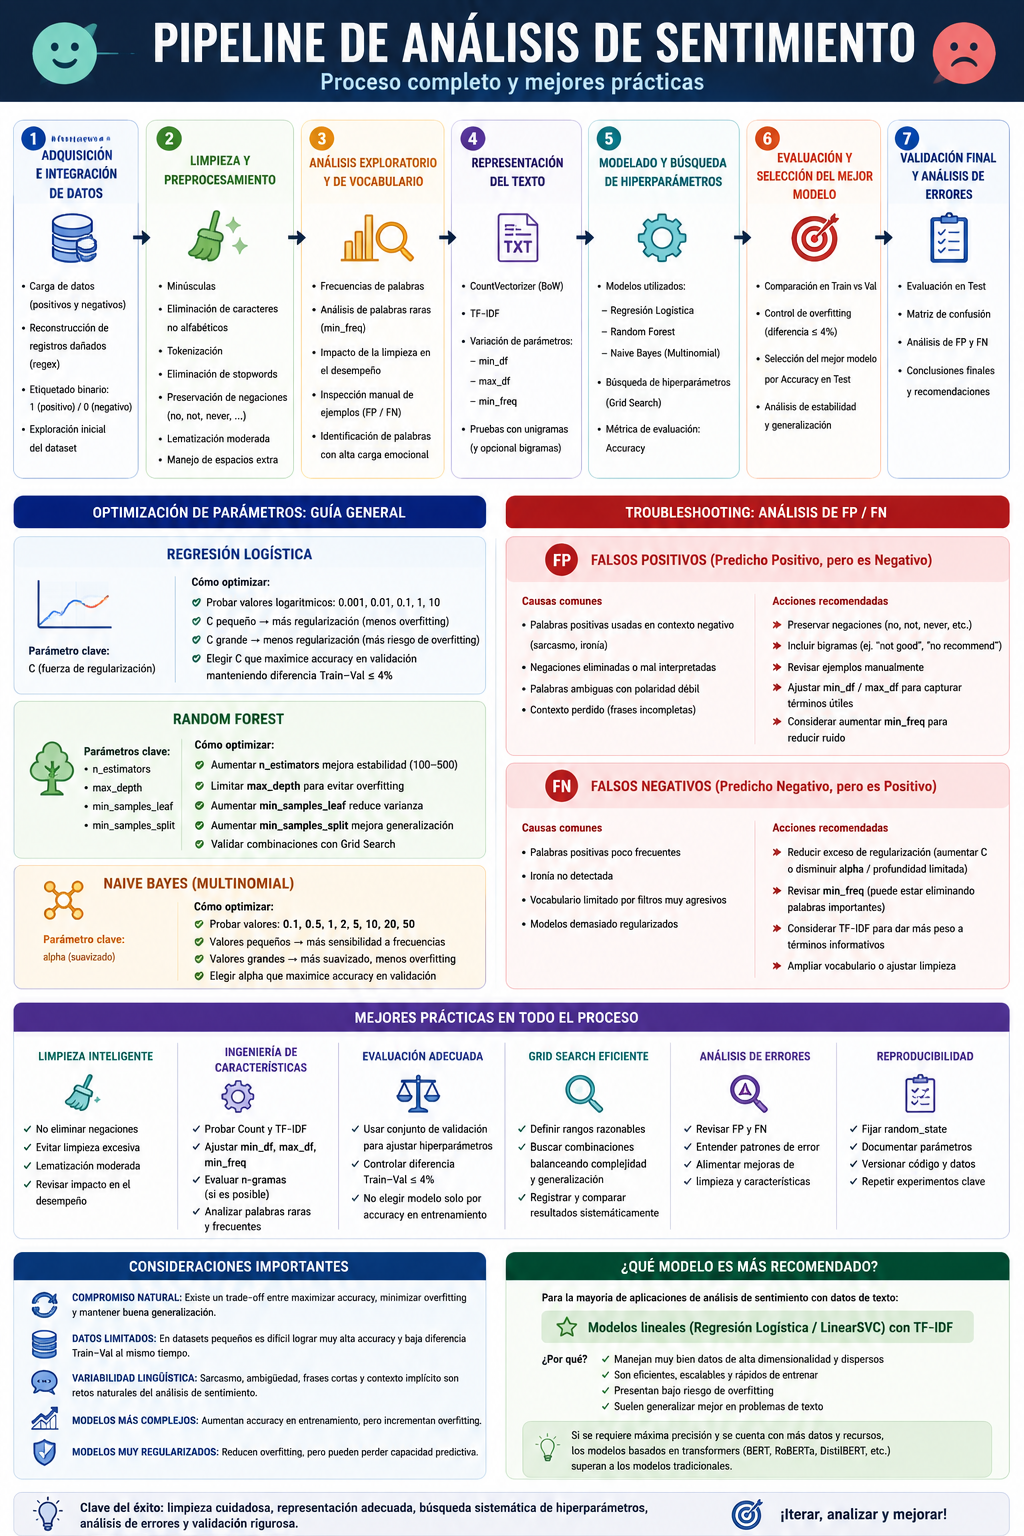

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**

## HELPERS and NOTES------- NOT PART OF THE ACTIVITY - PLEASE DISREGARD

#### Grid search for hyperparameters

In [294]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

resultados_final = []

# ============================================================
# 1. Logistic Regression - Count
# ============================================================
for C in [0.001, 0.003, 0.005,
 0.01, 0.02, 0.03, 0.05,
 0.07, 0.1, 0.15, 0.2,
 0.3, 0.5, 1]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "LR Count",
        f"C={C}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# 2. Logistic Regression - TFIDF
# ============================================================
for C in [0.001, 0.003, 0.005,
 0.01, 0.02, 0.03, 0.05,
 0.07, 0.1, 0.15, 0.2,
 0.3, 0.5, 1]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_tfidf, y_train)

    resultados_final.append([
        "LR TFIDF",
        f"C={C}",
        modelo.score(train_x_tfidf, y_train),
        modelo.score(val_x_tfidf, y_val),
        modelo.score(test_x_tfidf, y_test)
    ])


# ============================================================
# 3. Random Forest - Count
# ============================================================
for n_estimators in [150, 300, 500, 600]:
    for max_depth in [8, 10, 12, 15, 20, 25, 30]:
        for min_samples_leaf in [1, 2, 4, 6, 8, 10]:
            for min_samples_split in [2, 5, 10, 15, 20, 30]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_count, y_train)

                resultados_final.append([
                    "RF Count",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_count, y_train),
                    modelo.score(val_x_count, y_val),
                    modelo.score(test_x_count, y_test)
                ])


# ============================================================
# 4. Random Forest - TFIDF
# ============================================================
for n_estimators in [150, 300, 500]:
    for max_depth in [8, 10, 12, 15, 20, 25]:
        for min_samples_leaf in [1, 2, 4, 6, 8]:
            for min_samples_split in [2, 5, 10, 15, 20]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_tfidf, y_train)

                resultados_final.append([
                    "RF TFIDF",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo.score(train_x_tfidf, y_train),
                    modelo.score(val_x_tfidf, y_val),
                    modelo.score(test_x_tfidf, y_test)
                ])


# ============================================================
# 5. Naive Bayes - Count
# ============================================================
for alpha in [0.1, 0.3, 0.5, 1, 2, 3, 5, 10, 15, 20, 30, 50]:

    modelo = MultinomialNB(alpha=alpha)
    modelo.fit(train_x_count, y_train)

    resultados_final.append([
        "NB Count",
        f"alpha={alpha}",
        modelo.score(train_x_count, y_train),
        modelo.score(val_x_count, y_val),
        modelo.score(test_x_count, y_test)
    ])


# ============================================================
# Results
# ============================================================
df_final = pd.DataFrame(
    resultados_final,
    columns=["modelo", "params", "train_acc", "val_acc", "test_acc"]
)

df_final["diff_train_val"] = abs(df_final["train_acc"] - df_final["val_acc"])
df_final["diff_val_test"] = abs(df_final["val_acc"] - df_final["test_acc"])

display(df_final.sort_values(by="test_acc", ascending=False).head(100))

display(
    df_final[
        (df_final["test_acc"] > 0.79) &
        (df_final["diff_train_val"] < 0.04)
    ].sort_values(by="test_acc", ascending=False)
)

,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
208,RF Count,"n=150, depth=25, leaf=1, split=2",0.908571,0.804444,0.800000,0.104127,0.004444
245,RF Count,"n=150, depth=30, leaf=1, split=5",0.902857,0.808889,0.800000,0.093968,0.008889
712,RF Count,"n=500, depth=25, leaf=1, split=2",0.927143,0.804444,0.797778,0.122698,0.006667
246,RF Count,"n=150, depth=30, leaf=1, split=10",0.894286,0.800000,0.797778,0.094286,0.002222
27,LR TFIDF,C=1,0.907619,0.826667,0.795556,0.080952,0.031111
...,...,...,...,...,...,...,...
929,RF Count,"n=600, depth=20, leaf=1, split=5",0.900000,0.804444,0.786667,0.095556,0.017778
222,RF Count,"n=150, depth=25, leaf=4, split=10",0.837619,0.806667,0.786667,0.030952,0.020000
217,RF Count,"n=150, depth=25, leaf=2, split=15",0.851905,0.804444,0.786667,0.047460,0.017778
225,RF Count,"n=150, depth=25, leaf=4, split=30",0.838571,0.806667,0.786667,0.031905,0.020000


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test
187,RF Count,"n=150, depth=20, leaf=4, split=15",0.833333,0.800000,0.795556,0.033333,0.004444
184,RF Count,"n=150, depth=20, leaf=4, split=2",0.833333,0.804444,0.793333,0.028889,0.011111
185,RF Count,"n=150, depth=20, leaf=4, split=5",0.833333,0.804444,0.793333,0.028889,0.011111
186,RF Count,"n=150, depth=20, leaf=4, split=10",0.833333,0.802222,0.793333,0.031111,0.008889
188,RF Count,"n=150, depth=20, leaf=4, split=20",0.833333,0.800000,0.793333,0.033333,0.006667
189,RF Count,"n=150, depth=20, leaf=4, split=30",0.833333,0.804444,0.793333,0.028889,0.011111


### Grid Search for hyp including  best models

In [295]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

resultados_final = []

# ============================================================
# Helper function
# ============================================================

def guardar_resultado(nombre, params, modelo, x_train_m, x_val_m, x_test_m):
    resultados_final.append([
        nombre,
        params,
        modelo.score(x_train_m, y_train),
        modelo.score(x_val_m, y_val),
        modelo.score(x_test_m, y_test)
    ])


# ============================================================
# 1. Logistic Regression - Count
# ============================================================

for C in [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05,
          0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 1]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_count, y_train)

    guardar_resultado(
        "LR Count",
        f"C={C}",
        modelo,
        train_x_count,
        val_x_count,
        test_x_count
    )


# ============================================================
# 2. Logistic Regression - TFIDF
# ============================================================

for C in [0.001, 0.003, 0.005, 0.01, 0.02, 0.03, 0.05,
          0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 1]:

    modelo = LogisticRegression(
        C=C,
        max_iter=3000,
        random_state=1,
        solver="liblinear"
    )

    modelo.fit(train_x_tfidf, y_train)

    guardar_resultado(
        "LR TFIDF",
        f"C={C}",
        modelo,
        train_x_tfidf,
        val_x_tfidf,
        test_x_tfidf
    )


# ============================================================
# 3. Random Forest - Count
# ============================================================

for n_estimators in [150, 300, 500, 600]:
    for max_depth in [8, 10, 12, 15, 20, 25, 30]:
        for min_samples_leaf in [1, 2, 4, 6, 8, 10]:
            for min_samples_split in [2, 5, 10, 15, 20, 30]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_count, y_train)

                guardar_resultado(
                    "RF Count",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo,
                    train_x_count,
                    val_x_count,
                    test_x_count
                )


# ============================================================
# 4. Random Forest - TFIDF
# ============================================================

for n_estimators in [150, 300, 500, 600]:
    for max_depth in [8, 10, 12, 15, 20, 25, 30]:
        for min_samples_leaf in [1, 2, 4, 6, 8, 10]:
            for min_samples_split in [2, 5, 10, 15, 20, 30]:

                modelo = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    min_samples_split=min_samples_split,
                    random_state=1,
                    n_jobs=-1
                )

                modelo.fit(train_x_tfidf, y_train)

                guardar_resultado(
                    "RF TFIDF",
                    f"n={n_estimators}, depth={max_depth}, leaf={min_samples_leaf}, split={min_samples_split}",
                    modelo,
                    train_x_tfidf,
                    val_x_tfidf,
                    test_x_tfidf
                )


# ============================================================
# 5. Naive Bayes - Count
# ============================================================

for alpha in [0.1, 0.3, 0.5, 1, 2, 3, 5, 10, 15, 20, 30, 50]:

    modelo = MultinomialNB(alpha=alpha)
    modelo.fit(train_x_count, y_train)

    guardar_resultado(
        "NB Count",
        f"alpha={alpha}",
        modelo,
        train_x_count,
        val_x_count,
        test_x_count
    )


# ============================================================
# 6. Naive Bayes - TFIDF
# ============================================================

for alpha in [0.1, 0.3, 0.5, 1, 2, 3, 5, 10, 15, 20, 30, 50]:

    modelo = MultinomialNB(alpha=alpha)
    modelo.fit(train_x_tfidf, y_train)

    guardar_resultado(
        "NB TFIDF",
        f"alpha={alpha}",
        modelo,
        train_x_tfidf,
        val_x_tfidf,
        test_x_tfidf
    )


# ============================================================
# Results dataframe
# ============================================================

df_final = pd.DataFrame(
    resultados_final,
    columns=["modelo", "params", "train_acc", "val_acc", "test_acc"]
)

df_final["diff_train_val"] = abs(df_final["train_acc"] - df_final["val_acc"])
df_final["diff_val_test"] = abs(df_final["val_acc"] - df_final["test_acc"])

# Balanced score:
# Higher test accuracy is good.
# Lower train-val difference is good.
df_final["balanced_score"] = df_final["test_acc"] - df_final["diff_train_val"]


# ============================================================
# Best model for each family
# Count: LR, RF, NB
# TFIDF: LR, RF, NB
# ============================================================

best_each_model = (
    df_final
    .sort_values(
        by=["modelo", "balanced_score", "test_acc", "diff_train_val"],
        ascending=[True, False, False, True]
    )
    .groupby("modelo", as_index=False)
    .first()
)

display(best_each_model)


# ============================================================
# Models that meet the homework target
# test_acc > 0.79 and diff_train_val < 0.04
# ============================================================

target_models = df_final[
    (df_final["test_acc"] > 0.79) &
    (df_final["diff_train_val"] < 0.04)
].sort_values(
    by=["test_acc", "diff_train_val"],
    ascending=[False, True]
)

display(target_models)


# ============================================================
# Optional: top 10 models for each family
# ============================================================

top10_each_model = (
    df_final
    .sort_values(
        by=["modelo", "balanced_score", "test_acc", "diff_train_val"],
        ascending=[True, False, False, True]
    )
    .groupby("modelo")
    .head(10)
)

display(top10_each_model)

,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test,balanced_score
0,LR Count,C=0.1,0.871905,0.802222,0.780000,0.069683,0.022222,0.710317
1,LR TFIDF,C=0.005,0.849048,0.820000,0.764444,0.029048,0.055556,0.735397
2,NB Count,alpha=10,0.861905,0.811111,0.773333,0.050794,0.037778,0.722540
3,NB TFIDF,alpha=50,0.863810,0.815556,0.775556,0.048254,0.040000,0.727302
4,RF Count,"n=150, depth=20, leaf=4, split=2",0.833333,0.804444,0.793333,0.028889,0.011111,0.764444
5,RF TFIDF,"n=150, depth=15, leaf=8, split=2",0.809048,0.793333,0.755556,0.015714,0.037778,0.739841


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test,balanced_score
187,RF Count,"n=150, depth=20, leaf=4, split=15",0.833333,0.800000,0.795556,0.033333,0.004444,0.762222
184,RF Count,"n=150, depth=20, leaf=4, split=2",0.833333,0.804444,0.793333,0.028889,0.011111,0.764444
185,RF Count,"n=150, depth=20, leaf=4, split=5",0.833333,0.804444,0.793333,0.028889,0.011111,0.764444
189,RF Count,"n=150, depth=20, leaf=4, split=30",0.833333,0.804444,0.793333,0.028889,0.011111,0.764444
186,RF Count,"n=150, depth=20, leaf=4, split=10",0.833333,0.802222,0.793333,0.031111,0.008889,0.762222
188,RF Count,"n=150, depth=20, leaf=4, split=20",0.833333,0.800000,0.793333,0.033333,0.006667,0.760000


,modelo,params,train_acc,val_acc,test_acc,diff_train_val,diff_val_test,balanced_score
8,LR Count,C=0.1,0.871905,0.802222,0.780000,0.069683,0.022222,0.710317
6,LR Count,C=0.05,0.850952,0.788889,0.768889,0.062063,0.020000,0.706825
7,LR Count,C=0.07,0.860952,0.793333,0.773333,0.067619,0.020000,0.705714
10,LR Count,C=0.2,0.890000,0.804444,0.784444,0.085556,0.020000,0.698889
9,LR Count,C=0.15,0.883810,0.800000,0.782222,0.083810,0.017778,0.698413
5,LR Count,C=0.03,0.831429,0.775556,0.751111,0.055873,0.024444,0.695238
11,LR Count,C=0.3,0.898095,0.808889,0.780000,0.089206,0.028889,0.690794
12,LR Count,C=0.5,0.908095,0.806667,0.788889,0.101429,0.017778,0.687460
4,LR Count,C=0.02,0.810952,0.762222,0.731111,0.048730,0.031111,0.682381
13,LR Count,C=1,0.924286,0.811111,0.791111,0.113175,0.020000,0.677937


### Step 1 — Find FP and FN indices

In [296]:
import numpy as np

# ==================================================
# FALSE POSITIVES
# Real = 0 (negative)
# Predicted = 1 (positive)
# ==================================================

fp_idx = np.where((y_test == 0) & (pred == 1))[0]

# ==================================================
# FALSE NEGATIVES
# Real = 1 (positive)
# Predicted = 0 (negative)
# ==================================================

fn_idx = np.where((y_test == 1) & (pred == 0))[0]

print('Cantidad False Positives:', len(fp_idx))
print('Cantidad False Negatives:', len(fn_idx))

Cantidad False Positives: 29
Cantidad False Negatives: 64


### Step 2 — Print false positives

In [297]:
print('\n' + '='*80)
print('FALSE POSITIVES')
print('='*80)

for i in fp_idx[:20]:

    print('\n---')

    print('Etiqueta real     :', y_test.iloc[i])
    print('Predicción modelo :', pred[i])

    print('Comentario:')

    print(" ".join(x_test[i]))


FALSE POSITIVES

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
shame see good actor like thomerson james make living mess like

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
consistent thread holding series together amazing performance leni parker anita laselva two taelons quiet idealogical conflict

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
food way overpriced portion fucking small

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
tried like place time think done

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
loudspeaker option great bumper light appealing

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
watched price inflate portion get smaller management attitude grow rapidly

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
made case small difficult install

---
Etiqueta real     : 0
Predicción modelo : 1
Comentario:
service fair best

---
Etiqueta real     : 0
Predicción modelo : 1
Comen

In [298]:
from collections import Counter

fp_words = Counter()

for i in fp_idx:
    fp_words.update(x_test[i])

print('\nTop palabras en False Positives:\n')
print(fp_words.most_common(30))


Top palabras en False Positives:

[('like', 4), ('best', 4), ('small', 3), ('place', 3), ('made', 3), ('service', 3), ('flat', 3), ('film', 3), ('good', 2), ('actor', 2), ('make', 2), ('way', 2), ('portion', 2), ('management', 2), ('case', 2), ('vega', 2), ('grill', 2), ('high', 2), ('taste', 2), ('dining', 2), ('shame', 1), ('see', 1), ('thomerson', 1), ('james', 1), ('living', 1), ('mess', 1), ('consistent', 1), ('thread', 1), ('holding', 1), ('series', 1)]


### Step 3 — Print false negatives

In [299]:
print('\n' + '='*80)
print('FALSE NEGATIVES')
print('='*80)

for i in fn_idx[:20]:

    print('\n---')

    print('Etiqueta real     :', y_test.iloc[i])
    print('Predicción modelo :', pred[i])

    print('Comentario:')

    print(" ".join(x_test[i]))


FALSE NEGATIVES

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
food arrived quickly

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
food rich order accordingly

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
linked phone without effort

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
back many time soon

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
bacon hella salty

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
not miss

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
one place phoenix would definately go back

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
not familiar check

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
noise shield incrediable

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
ended sliding edge pant back pocket instead

---
Etiqueta real     : 1
Predicción modelo : 0
Comentario:
plus buck

---
Etiqueta real     : 1
Predicción modelo : 

In [300]:
fn_words = Counter()

for i in fn_idx:
    fn_words.update(x_test[i])

print('\nTop palabras en False Negatives:\n')
print(fn_words.most_common(30))


Top palabras en False Negatives:

[('not', 13), ('back', 7), ('would', 7), ('time', 6), ('movie', 6), ('go', 5), ('food', 4), ('place', 4), ('steak', 4), ('order', 3), ('actually', 3), ('long', 3), ('every', 3), ('recommend', 3), ('service', 3), ('car', 3), ('lot', 3), ('film', 3), ('went', 3), ('much', 3), ('even', 3), ('vega', 3), ('like', 3), ('phone', 2), ('edge', 2), ('instead', 2), ('next', 2), ('trip', 2), ('turn', 2), ('minute', 2)]
